In [1]:
import numpy as np
import matplotlib.pyplot as plt

import specula
specula.init(-1)  # CPU execution
from scipy.integrate import simpson as simps
from specula.data_objects.iir_filter_data import IirFilterData

Cupy import successfull. Installed version is: 13.6.0
Default device is CPU


In [2]:
def von_karman_power(n,r0,L0,D):
    C = 0.02289558710855519
    B = (n/D)**2 + (D/L0)**2
    return C * (r0/D)**(-5.0/3.0) * B**(-11.0/6.0)

def analytic_turb_psd(f, n, r0, L0, D, V):
    psd = np.ones_like(f)
    fc = 0.3 * (n+1) * V/D
    if n == 1: # tilt modes
        psd[f<=fc] = (f[f<=fc] / fc) ** (-2.0/3.0) 
    psd[f > fc] = (f[f > fc] / fc)**(-17/3)
    # Normalize to turbulence Von-Karman power
    vkp = von_karman_power(n, r0, L0, D)
    psd *= vkp/simps(psd,f)
    return psd

In [3]:
r0 = 3e-2
D = 1.82

tt_req = 6*np.sqrt(0.87*(D/r0)**(5/3))*2*500e-9/(2*np.pi)
tt_got = 6e-6

print(tt_req)

2.725980758753581e-05


(1e-16, 1e-08)

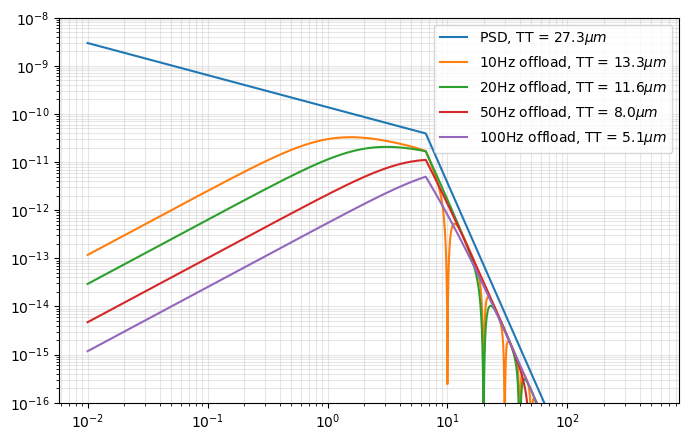

In [36]:
fs = 1e+3
fvec = np.logspace(-2,np.log10(fs/2),2000)
psd = analytic_turb_psd(f=fvec, n=1, D=D, r0=r0, V = 20, L0 = 25)
psd *= tt_req**2/simps(psd,fvec)

leaky_int = IirFilterData.from_gain_and_ff(gain=[1.0],ff=[1.0])
frames_delay=1.0
nw_delay, dw_delay = leaky_int.discrete_delay_tf(frames_delay)

plt.figure(figsize=(8,5))
dm_stroke = np.sqrt(simps(psd,fvec))
plt.loglog(fvec, psd, label=f'PSD, TT = {dm_stroke*1e+6:1.1f}'+r'$\mu m$')
for f in np.array([10,20,50,100]):
    rtf = leaky_int.RTF(mode=0,fs=f,freq=fvec,dm=1.0,dw_delay=dw_delay,nw_delay=nw_delay,plot=False)  
    res = psd * rtf**2 
    dm_stroke = np.sqrt(simps(res,fvec))
    plt.loglog(fvec, res,label=f'{f}Hz offload, TT = {dm_stroke*1e+6:1.1f}'+r'$\mu m$')
plt.legend(loc='best')
plt.grid(which='both',alpha=0.3)
plt.ylim([1e-16,1e-8])
